# 13.4 USDA Food Database

## 1. Thông tin về dữ liệu

USDA Food Database (tên hiện nay là FoodData Central) là kho dữ liệu dinh dưỡng do Bộ Nông nghiệp Hoa Kỳ (USDA) duy trì. Nó tập hợp và chuẩn hóa thông tin dinh dưỡng của hàng chục nghìn thực phẩm—từ nguyên liệu thô (như thịt, rau, ngũ cốc) đến món chế biến sẵn và sản phẩm đóng gói có nhãn.

Lập trình viên Ashley Williams đã tạo ra một phiên bản JSON của cơ sở dữ liệu này, giúp chúng ta dễ dàng thao tác bằng Python.

In [1]:
import json
import pandas as pd
db = json.load(open("dataset/usda_food/database.json"))

info_keys = ["description", "group", "id", "manufacturer"]
info = pd.DataFrame(db, columns=info_keys)
info.head()
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6636 entries, 0 to 6635
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   description   6636 non-null   object
 1   group         6636 non-null   object
 2   id            6636 non-null   int64 
 3   manufacturer  5195 non-null   object
dtypes: int64(1), object(3)
memory usage: 207.5+ KB


**Nhận xét:**
- Bộ dữ liệu bao gồm 4 cột và 6636 dòng, thông tin các cột:

<!-- Dán nguyên khối này vào Markdown (HTML trong Markdown) -->
<div align="center">
  <table style="border-collapse:collapse; margin:auto;">
    <thead>
      <tr>
        <th style="border:1px solid #ccc; padding:10px; text-align:center;">Tên cột</th>
        <th style="border:1px solid #ccc; padding:10px; text-align:center;">Ý nghĩa</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="border:1px solid #ccc; padding:10px; text-align:center;">description</td>
        <td style="border:1px solid #ccc; padding:10px; text-align:center;">Tên/miêu tả của thực phẩm hoặc sản phẩm</td>
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:10px; text-align:center;">group</td>
        <td style="border:1px solid #ccc; padding:10px; text-align:center;">Nhóm thực phẩm (ngũ cốc, thịt, đồ uống…)</td>
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:10px; text-align:center;">id</td>
        <td style="border:1px solid #ccc; padding:10px; text-align:center;">Mã định danh duy nhất cho từng mục</td>
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:10px; text-align:center;">manufacturer</td>
        <td style="border:1px solid #ccc; padding:10px; text-align:center;">Nhà sản xuất/thương hiệu (có thể trống)</td>
      </tr>
    </tbody>
  </table>
</div>



## 2 Kiểm tra tính toàn vẹn của dữ liệu
+ Dữ liệu có bị trùng lặp không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị Null không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị NaN không? Hiển thị dòng bị vi phạm.

In [33]:
has_null = info.isnull().sum().any()
has_duplicate = info.duplicated().sum()
print(f"Giá trị Null: {has_null}")
if has_null:
    display(info[info.isnull().any(axis = 1)])
   
print(f"Giá trị duplicated: {has_duplicate}")


Giá trị Null: True


,description,group,id,manufacturer
15,"Milk, reduced fat, fluid, 2% milkfat, with add...",Dairy and Egg Products,1079,None
47,"Sour cream, reduced fat",Dairy and Egg Products,1178,None
48,"Sour cream, light",Dairy and Egg Products,1179,None
49,"Sour cream, fat free",Dairy and Egg Products,1180,None
50,"USDA Commodity, cheese, cheddar, reduced fat",Dairy and Egg Products,1182,None
...,...,...,...,...
6467,"Rolls, dinner, plain, commercially prepared (i...",Baked Products,18342,None
6468,"Rolls, dinner, whole-wheat",Baked Products,18348,None
6633,"Babyfood, juice, pear",Baby Foods,43408,None
6634,"Babyfood, dessert, banana yogurt, strained",Baby Foods,43539,None


Giá trị duplicated: 0


**Nhận xét**:

Như thông tin các cột trên, có thể thấy toàn bộ dữ liệu có tới 6636 dòng, nhưng ở cột manufacturer bị trống. Tuy nhiên trong thực tế không phải mặt hàng nào cũng có “nhà sản xuất”:

- Thực phẩm thô/không nhãn (Foundation/SR Legacy/FNDDS): ví dụ “Apple, raw” hay “Beef, raw” không thuộc một hãng cụ thể ⇒ không có manufacturer.

- Sản phẩm có nhãn (Branded Foods): ví dụ “Kellogg’s Corn Flakes” ⇒ có manufacturer: "Kellogg’s".

## 3. Phân tích mô tả

### 3.1. Xem thông tin thành phần các keys trong JSON

In [ ]:
db[0].keys()
key_df = pd.DataFrame(db[0].keys())
key_df.head(7)

,0
0,id
1,description
2,tags
3,manufacturer
4,group
5,portions
6,nutrients


**Nhận xét:**

Các thành phần keys có trong JSON:

<!-- Bảng tên cột & ý nghĩa (HTML trong Markdown, căn giữa) -->
<div align="center">
  <table style="border-collapse:collapse; margin:auto;">
    <thead>
      <tr>
        <th style="border:1px solid #ccc; padding:10px; text-align:center;">Tên cột</th>
        <th style="border:1px solid #ccc; padding:10px; text-align:center;">Ý nghĩa</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">id</td>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">Mã định danh duy nhất của thực phẩm/sản phẩm</td>
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">description</td>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">Tên/miêu tả chi tiết của thực phẩm</td>
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">tags</td>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">Các nhãn/từ khóa liên quan </td>
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">manufacturer</td>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">Nhà sản xuất/thương hiệu</td>
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">group</td>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">Nhóm/danh mục thực phẩm 
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">portions</td>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">Danh sách khẩu phần 
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">nutrients</td>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">Danh sách chất dinh dưỡng 
      </tr>
    </tbody>
  </table>
</div>

> Các cột đều quan trọng, tuy nhiên ta chỉ quan tâm đến các cột $nutrients$ vì nó chứa thông tin cần thiết


#### 3.1.1. Khám phá Nutrients

In [52]:
db[0].keys()
db[0]["nutrients"][0]
nutrients = pd.DataFrame(db[0]["nutrients"])
nutrients.head(7)

,value,units,description,group
0,25.18,g,Protein,Composition
1,29.20,g,Total lipid (fat),Composition
2,3.06,g,"Carbohydrate, by difference",Composition
3,3.28,g,Ash,Other
4,376.00,kcal,Energy,Energy
5,39.28,g,Water,Composition
6,1573.00,kJ,Energy,Energy


**Nhận xét:**

Các thành phần có trong cột $nutrients$

edit mardown this table
     


> Các cột đều quan trọng, tuy nhiên ta chỉ quan tâm đến các cột $nutrients$ vì nó chứa thông tin cần thiết


In [53]:
display(f"nan: {nutrients.isna().sum().any()}")
display(f"Số dòng bị trùng: {nutrients.duplicated().sum()}")

'nan: False'

'Số dòng bị trùng: 108'

**Nhận xét:**
- Đối với key là $nutrients$ không có missing values tuy nhiên có tới 108 dòng bị trùng, cần giảm số dòng trùng lại để tối ưu dữ liệu.

In [54]:
nutrients = nutrients.drop_duplicates()
display(f"Số dòng bị trùng: {nutrients.duplicated().sum()}")

'Số dòng bị trùng: 0'

**Nhận xét:**
- Sau khi drop các dòng bị trùng, dữ liệu có thể tối ưu nhất. Tuy nhiên tên của các cột đang bị khó 

1) Trung bình năng lượng (kcal) của từng nhóm thực phẩm là bao nhiêu?

- Tính trung bình Kcal
- Group by theo group thực phẩm
- Vẽ barchart

2) Loại thực phẩm nào chứa protein cao nhất trong nhóm “Dairy and Egg Products”?


- lấy value có trong nutrients
- lấy group “Dairy and Egg Products” 
-> Group by 2 nhóm này và vẽ barh

3) Các nhóm thực phẩm nào phổ biến trong dataset?

In [ ]:
pd.value_counts(info["group"])[:10]

C:\Users\luong\AppData\Local\Temp\ipykernel_16512\3634668934.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(info["group"])[:10]


group
Vegetables and Vegetable Products    812
Beef Products                        618
Baked Products                       496
Breakfast Cereals                    403
Legumes and Legume Products          365
Fast Foods                           365
Lamb, Veal, and Game Products        345
Sweets                               341
Fruits and Fruit Juices              328
Pork Products                        328
Name: count, dtype: int64

C:\Users\luong\AppData\Local\Temp\ipykernel_7360\2991066696.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  group_counts = pd.value_counts(info["group"])[:]


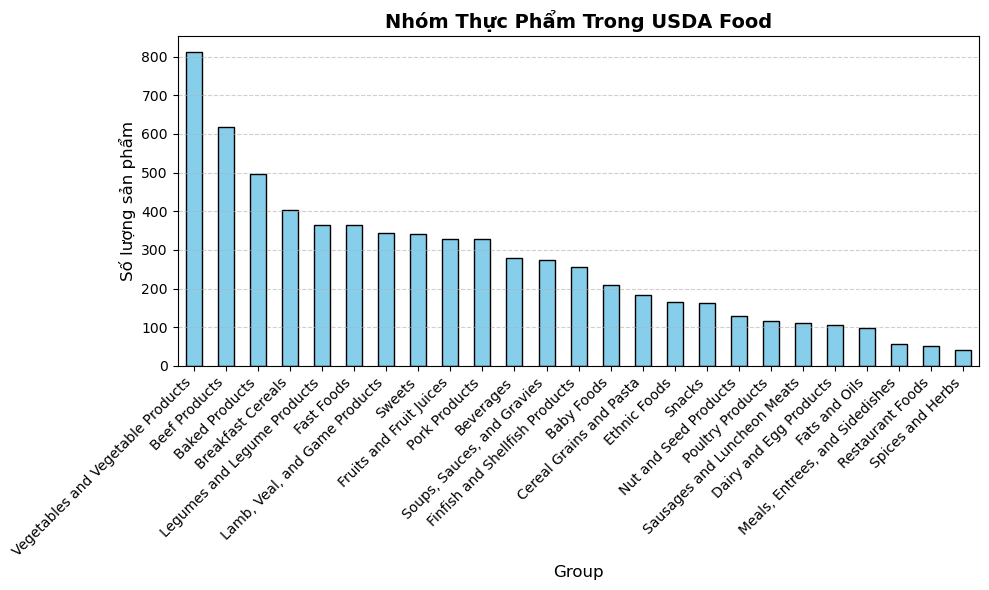

In [58]:
import matplotlib.pyplot as plt
group_counts = pd.value_counts(info["group"])[:]

plt.figure(figsize=(10,6))
group_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Nhóm Thực Phẩm Trong USDA Food", fontsize=14, weight='bold')
plt.xlabel("Group", fontsize=12)
plt.ylabel("Số lượng sản phẩm", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('top_10_groups.png', dpi=300, bbox_inches='tight')
plt.show()


**Nhận xét:**
- Trong toàn bộ nhóm sản phẩm nổi bật thì các loại rau củ (~800), sản phẩm từ thịt bò (~600) và sản phẩm đồ nướng (500) là các nhóm có độ phổ biến cũng như số lượng cao nhất trong toàn bộ nhóm sản phẩm.



## 4. Phân tích so sánh

+ So sánh hàm lượng protein và lipid (chất béo) giữa nhóm “Meat” và “Dairy”?
+ Tỷ lệ Energy-to-Protein khác biệt thế nào giữa nhóm “Grains” và “Vegetables”?
→ dùng pivot_table(values='value', index='group', columns='description').

## 5. Phân tích tương quan

+ Có mối tương quan nào giữa năng lượng (Energy) và hàm lượng chất béo (Fat)?
→ ndata.pivot(...) → tính corr().
+ Nhóm thực phẩm nào có năng lượng cao nhưng protein thấp (chất “rỗng”)?
+ Các loại thực phẩm giàu “Water” có xu hướng ít năng lượng hơn không?

## 3. Phân tích mô tả